In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd

In [2]:
#load data and did hot encoding 
heart_data=pd.read_csv('heart.csv')
y=heart_data["HeartDisease"]
X=heart_data.drop(columns=["HeartDisease",])

variable=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
X=pd.get_dummies(data=X,prefix=variable,columns=variable)
print(X.dtypes)

Age                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
Oldpeak              float64
Sex_F                   bool
Sex_M                   bool
ChestPainType_ASY       bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_LVH          bool
RestingECG_Normal       bool
RestingECG_ST           bool
ExerciseAngina_N        bool
ExerciseAngina_Y        bool
ST_Slope_Down           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object


In [15]:

x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=0.4,random_state=55)


#scale train and test data
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_val=scaler.transform(x_val)



In [16]:
min_split_size=[10,20,100,20,300,400,500,600,700]


In [17]:
r2_train=[]
r2_val=[]
#choose best min split size in randomforest
for min_split in min_split_size:
    model=RandomForestClassifier(min_samples_split=min_split,random_state=1234).fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    acc_train=accuracy_score(y_train,y_train_predict)
    acc_val=accuracy_score(y_val,y_val_predict)
    r2_train.append(acc_train)
    r2_val.append(acc_val)


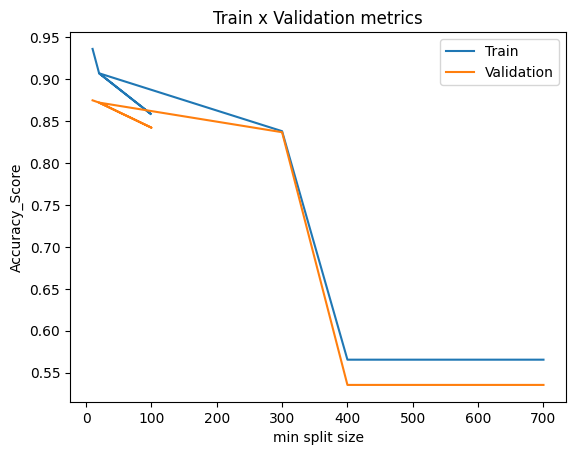

In [18]:
plt.plot(min_split_size,r2_train)
plt.plot(min_split_size,r2_val)
plt.ylabel('Accuracy_Score')
plt.xlabel('min split size')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [19]:
index=np.argmax(r2_val)
min_split=min_split_size[index]
min_split

10

In [20]:
max_depth_size=[2,4,8,16,32,64,None]
r2_train_list=[]
r2_val_list=[]

for max_depth in max_depth_size:
    model=RandomForestClassifier(max_depth=max_depth,min_samples_split=min_split,random_state=55).fit(X,y)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    r2_train=accuracy_score(y_train,y_train_predict)
    r2_val=accuracy_score(y_val,y_val_predict)
    r2_train_list.append(r2_train)
    r2_val_list.append(r2_val)

    

/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but 

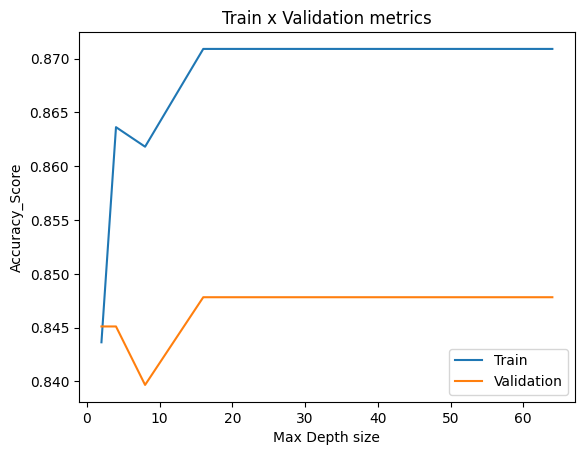

In [21]:
plt.plot(max_depth_size,r2_train_list)
plt.plot(max_depth_size,r2_val_list)
plt.ylabel('Accuracy_Score')
plt.xlabel('Max Depth size')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [22]:
index_depth=np.argmax(r2_val_list)
max_depth=max_depth_size[index_depth]
max_depth

16

In [23]:
n_estimator_list=[10,100,200,300,400]
r2_train_list=[]
r2_val_list=[]

for n_estimator in n_estimator_list:
    model=RandomForestClassifier(n_estimators=n_estimator,max_depth=max_depth,min_samples_split=min_split,random_state=55).fit(X,y)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    r2_train=accuracy_score(y_train,y_train_predict)
    r2_val=accuracy_score(y_val,y_val_predict)
    r2_train_list.append(r2_train)
    r2_val_list.append(r2_val)


/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but 

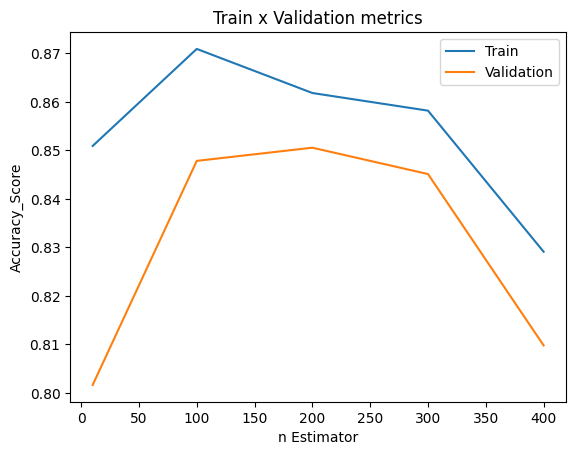

In [24]:
plt.plot(n_estimator_list,r2_train_list)
plt.plot(n_estimator_list,r2_val_list)
plt.xlabel
plt.ylabel('Accuracy_Score')
plt.xlabel('n Estimator')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [25]:
index_opt_estimator=np.argmax(r2_val_list)
opt_estimator=n_estimator_list[index_opt_estimator]
opt_estimator

200

In [23]:
Heart_Classification_model=RandomForestClassifier(n_estimators=n_estimator,max_depth=max_depth,min_samples_split=min_split,random_state=55).fit(x_train,y_train)

In [25]:
pickle.dump(Heart_Classification_model,open("Heart_Classification_model.pkl","wb"))